<a href="https://colab.research.google.com/github/ameliagarciarond22-source/Modelos-Estoc-sticos-/blob/main/Tutorial_de_Sympy_y_Networkx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librería Sympy y diagramas con NetworkX

###1. Introducción

En este tutorial se presentan algunas operaciones básicas con matrices utilizando la librería SymPy de Python. SymPy es una biblioteca para matemáticas simbólicas que permite trabajar con matrices, resolver sistemas de ecuaciones y calcular valores propios de manera exacta.

También se introduce la librería NetworkX, que permite construir y visualizar grafos, lo cual es útil para representar diagramas de transición, por ejemplo en cadenas de Markov.

##2. Instalación de librerías

Antes de comenzar a trabajar es necesario instalar las librerías que se utilizarán


```
!pip install sympy
!pip install networkx
!pip install matplotlib
```



##3. Importar librerías
La instrucción import permite cargar una librería completa o parte de ella dentro del programa, para poder utilizar sus funciones.


```
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt
```



##4. Creación de matrices en SymPy

En SymPy las matrices se crean con Matrix.
A continuación se crean dos matrices de ejemplo.


```
A = sp.Matrix([
    [1, 2],
    [3, 4]
])

B = sp.Matrix([
    [0, 1],
    [1, 0]
])

A, B
```



##5. Multiplicación de vectores con matrices

Podemos multiplicar una matriz por un vector columna.

Esta operación aparece frecuentemente en modelos estocásticos, donde un vector de probabilidades de estado se multiplica por una matriz de transición para obtener la distribución de probabilidad en el siguiente paso del proceso.

En SymPy, los vectores también se representan mediante el objeto Matrix, pero en forma de vector columna.


```
v = sp.Matrix([
    [1],
    [2]
])

resultado = A * v
resultado
```



Matemáticamente, esta operación corresponde a

$$
A\mathbf{v} = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix} \begin{pmatrix} 1 \\ 2 \end{pmatrix} = \begin{pmatrix} 5 \\ 11 \end{pmatrix}
$$

##6. Potencias de matrices

En SymPy podemos calcular potencias de matrices usando **

Esto es útil, por ejemplo, para estudiar transiciones en cadenas de Markov, donde la potencia de la matriz indica transiciones en varios pasos.

In [11]:
A2 = A**2
A3 = A**3

print("A^2 =")
display(A2)

print("A^3 =")
display(A3)

A^2 =


Matrix([
[ 7, 10],
[15, 22]])

A^3 =


Matrix([
[37,  54],
[81, 118]])

##7. Solución de sistemas de ecuaciones lineales

Consideremos el sistema:

$$
\begin{cases}
x + 2y = 5 \\
3x + 4y = 11
\end{cases}
$$

el resultado será:
$$
x = 1, y = 2
$$

In [12]:
x, y = sp.symbols('x y')

A = sp.Matrix([
    [1, 2],
    [3, 4]
])

b = sp.Matrix([
    [5],
    [11]
])

solucion = A.LUsolve(b)
solucion

Matrix([
[1],
[2]])

##8. Cálculo de valores propios

Los valores propios se obtienen con eigenvals().

In [13]:
A = sp.Matrix([
    [1, 2],
    [3, 4]
])

valores_propios = A.eigenvals()
valores_propios

{5/2 - sqrt(33)/2: 1, 5/2 + sqrt(33)/2: 1}

Esto devuelve un diccionario donde la clave es el valor propio y el valor es su multiplicidad.
En este caso, los valores propios son:
$$
\frac{5}{2} - \frac{\sqrt{33}}{2}: 1,
\\
\quad \frac{5}{2} + \frac{\sqrt{33}}{2}: 1
\\
$$
ambos con multiplicidad 1.

##9. Cálculo de vectores propios

Para obtener los vectores propios usamos eigenvects().

In [14]:
vectores_propios = A.eigenvects()
vectores_propios

[(5/2 - sqrt(33)/2,
  1,
  [Matrix([
   [-sqrt(33)/6 - 1/2],
   [                1]])]),
 (5/2 + sqrt(33)/2,
  1,
  [Matrix([
   [-1/2 + sqrt(33)/6],
   [                1]])])]

La salida tiene la forma:
```
# (valor propio, multiplicidad, [vectores propios])
```
$$
\left[
  \left( \frac{5}{2} - \frac{\sqrt{33}}{2}, 1, \left[ \begin{bmatrix} -\frac{\sqrt{33}}{6} - \frac{1}{2} \\ 1 \end{bmatrix} \right] \right),
  \left( \frac{5}{2} + \frac{\sqrt{33}}{2}, 1, \left[ \begin{bmatrix} -\frac{1}{2} + \frac{\sqrt{33}}{6} \\ 1 \end{bmatrix} \right] \right)
\right]
$$

##10. Introducción a NetworkX

NetworkX es una librería para trabajar con grafos en Python.

Un diagrama de transición puede representarse como un grafo dirigido.

##11. Crear un grafo de transición

Supongamos tres estados:
S = {A, B, C}

In [15]:
G = nx.DiGraph()

G.add_edge("A", "B", weight=0.5)
G.add_edge("A", "C", weight=0.5)
G.add_edge("B", "A", weight=0.3)
G.add_edge("B", "C", weight=0.7)
G.add_edge("C", "C", weight=1.0)

##12. Dibujar el diagrama de transición

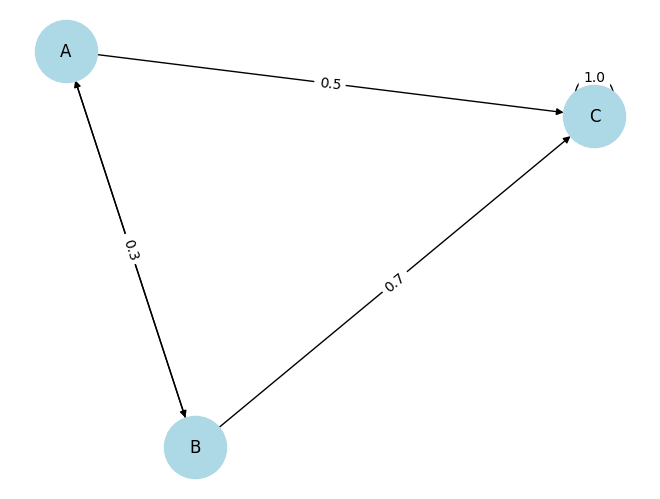

In [16]:
pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=2000,
    font_size=12
)

labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.show()

Esto genera un diagrama de transición donde:


*   Los nodos representan estados
*   Las flechas representan transiciones
*   Las etiquetas indican probabilidadeS






